## Volatility regime detection with Hidden Markov Model ##

### Appendix - What if all vols? ###


Paulo Yoshio Kuga


**Abstract**

In the previous notebook, we used log parkinson as a way to adapt a HMM as representative of our volatility dynamics. But what if we could compare all volatilties?


In [8]:
import pandas as pd
from matplotlib import pyplot as plt
import bandeirante as bd
import numpy as np

from hmmlearn.hmm import GaussianHMM

import yfinance as yf

from datetime import datetime

Again, we use our yfinance data and calculates all the volatilities, using a window of 21 days. 

In [9]:
start_date = datetime(2016,1,1)
end_date = datetime.today()

ticker = "^BVSP"

dataset = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    interval="1d"
    ).droplevel(axis=1,level=1)

w = 21 #general volatility window

dataset["returns"] = dataset["Close"].pct_change().add(1).apply(np.log).dropna()
dataset["vol_std"] = np.log(dataset.returns.rolling(w).std().dropna())

dataset["vol_PK"] = np.log(bd.parkinson(dataset,w,max_str="High",min_str="Low"))
dataset["vol_GK"] = np.log(bd.garman_klass(dataset,w,max_str="High",min_str="Low",close_str="Close",open_str="Open"))
dataset["vol_RS"] = np.log(bd.rogers_satchell(dataset,w,max_str="High",min_str="Low",close_str="Close",open_str="Open"))
dataset["vol_YZ"] = np.log(bd.yang_zhang(dataset,w,max_str="High",min_str="Low",close_str="Close",open_str="Open"))

dataset.dropna(inplace=True) #to assure consistency along the dataset

[*********************100%***********************]  1 of 1 completed


We can plot the log-returns and the two types of volatility. It is possible to notice that, usually, Parkinson volatility tends to be more conservative along the time. It is known that statistical standard deviation volatility tends to superestimate volatility true value.

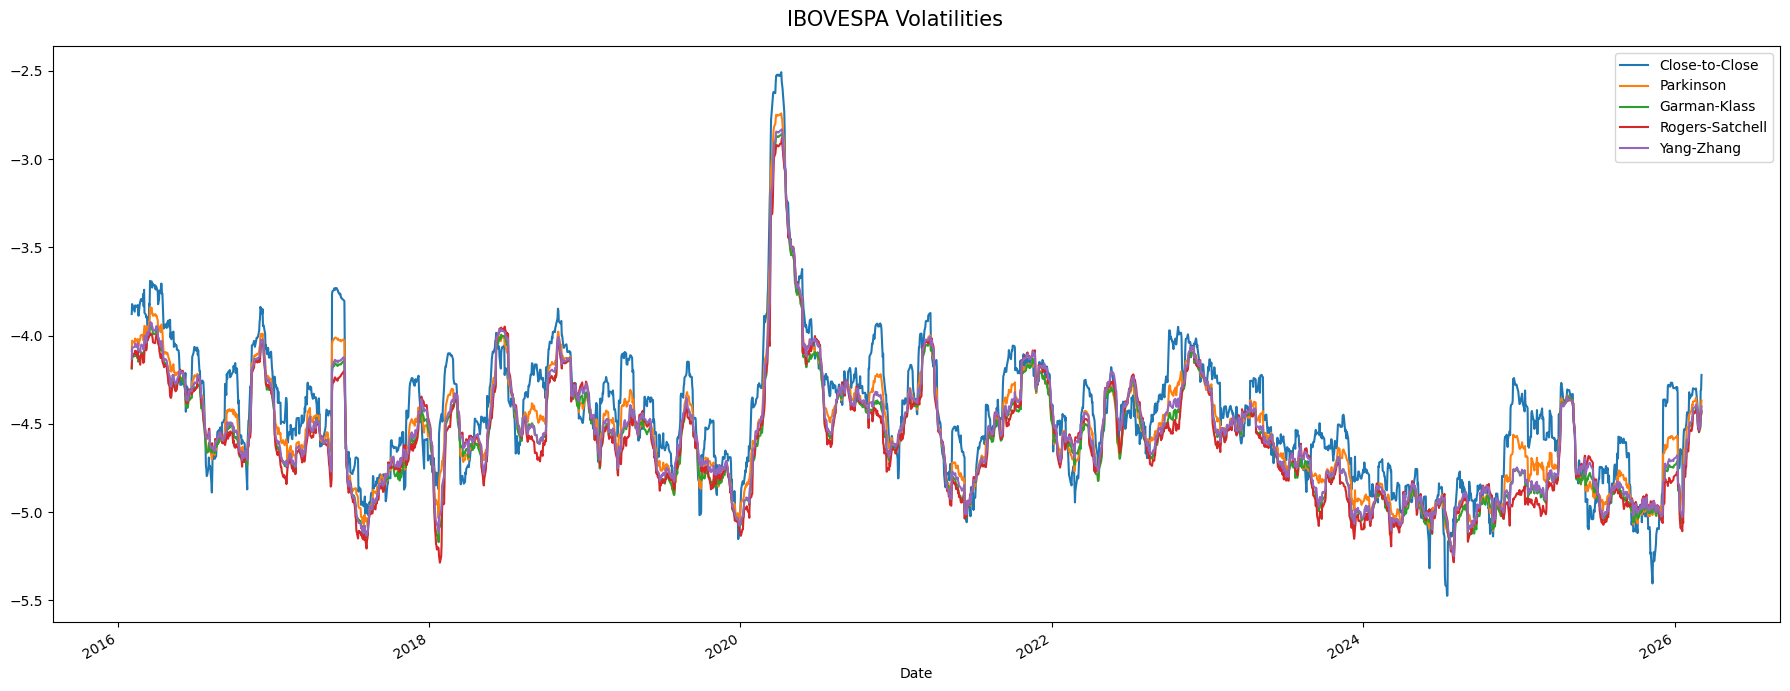

In [10]:
fig,axs = plt.subplots(1,1, figsize=(18,7),sharex=True)

dataset["vol_std"].plot(ax=axs)
dataset["vol_PK"].plot(ax=axs)
dataset["vol_GK"].plot(ax=axs)
dataset["vol_RS"].plot(ax=axs)
dataset["vol_YZ"].plot(ax=axs)

fig.suptitle("IBOVESPA Volatilities",fontsize=15)

axs.legend(["Close-to-Close","Parkinson","Garman-Klass","Rogers-Satchell","Yang-Zhang"])


fig.tight_layout()

As before, we set our models.

In [11]:
def hmm_model_generator(
        vol, 
        n = 3,
        anti_stall = 1,
        train_test_percentual = 0.7,
        random_state = 20000728
        ):

    X = vol.to_numpy().reshape(-1,1)*anti_stall

    series_length,_ = X.shape  

    cut_value = int(np.ceil((series_length*train_test_percentual)))

    X_train= X[:cut_value]

    hmm_model = GaussianHMM(n_components=n,covariance_type="full",random_state=random_state)

    hmm_model.fit(X_train)

    return hmm_model,X, cut_value


def state_as_stationary(hmm_model,n_states):
    stationary = hmm_model.get_stationary_distribution()

    states_order = dict(
    zip(
        np.argsort(stationary)[::-1],np.array(range(0,n_states))
        )
    )
    order_function = np.vectorize(states_order.get)

    return order_function


We set our number of states as 3 for all vols. These 3 states could be characterized as levels of volatility intensity and the type of regime, such as "low-vol", "mid-vol" and "high-vol". We predict the states for the entire series, and when predicting, re-ordering the states to adhere our convention.


In [12]:
n_states = 3

hmm_model_std, X_std, cut_value, = hmm_model_generator(dataset.vol_std)
hmm_model_parkinson, X_parkinson, _ = hmm_model_generator(dataset.vol_PK)
hmm_model_GK, X_GK, _ = hmm_model_generator(dataset.vol_GK)
hmm_model_RS, X_RS, _ = hmm_model_generator(dataset.vol_RS)
hmm_model_YZ, X_YZ, _ = hmm_model_generator(dataset.vol_YZ)

prediction_std = state_as_stationary(hmm_model_std,n_states)(hmm_model_std.predict(X_std))
prediction_parkinson = state_as_stationary(hmm_model_parkinson,n_states)(hmm_model_parkinson.predict(X_parkinson))
prediction_GK = state_as_stationary(hmm_model_GK,n_states)(hmm_model_std.predict(X_GK))
prediction_RS = state_as_stationary(hmm_model_RS,n_states)(hmm_model_std.predict(X_RS))
prediction_YZ = state_as_stationary(hmm_model_YZ,n_states)(hmm_model_std.predict(X_YZ))


dataset["state_std"] = prediction_std
dataset["state_PK"] = prediction_parkinson
dataset["state_GK"] = prediction_GK
dataset["state_RS"] = prediction_RS
dataset["state_YZ"] = prediction_YZ

After this, using add_state_background function in Bandeirante, we can plot our states as coloured backgrounds:

In [13]:
def plot_states_and_series(dataset,series_name,state_name,ax,cut_value,pallette="YlOrRd",states=3):
    dataset[series_name].plot(ax=ax)
    bd.add_state_background(dataset,series_name,state_name,n=states,ax=ax,chosenPallete=pallette)
    ax.axvline(x=dataset.index[cut_value], color='r', linestyle='dashed', linewidth=2)


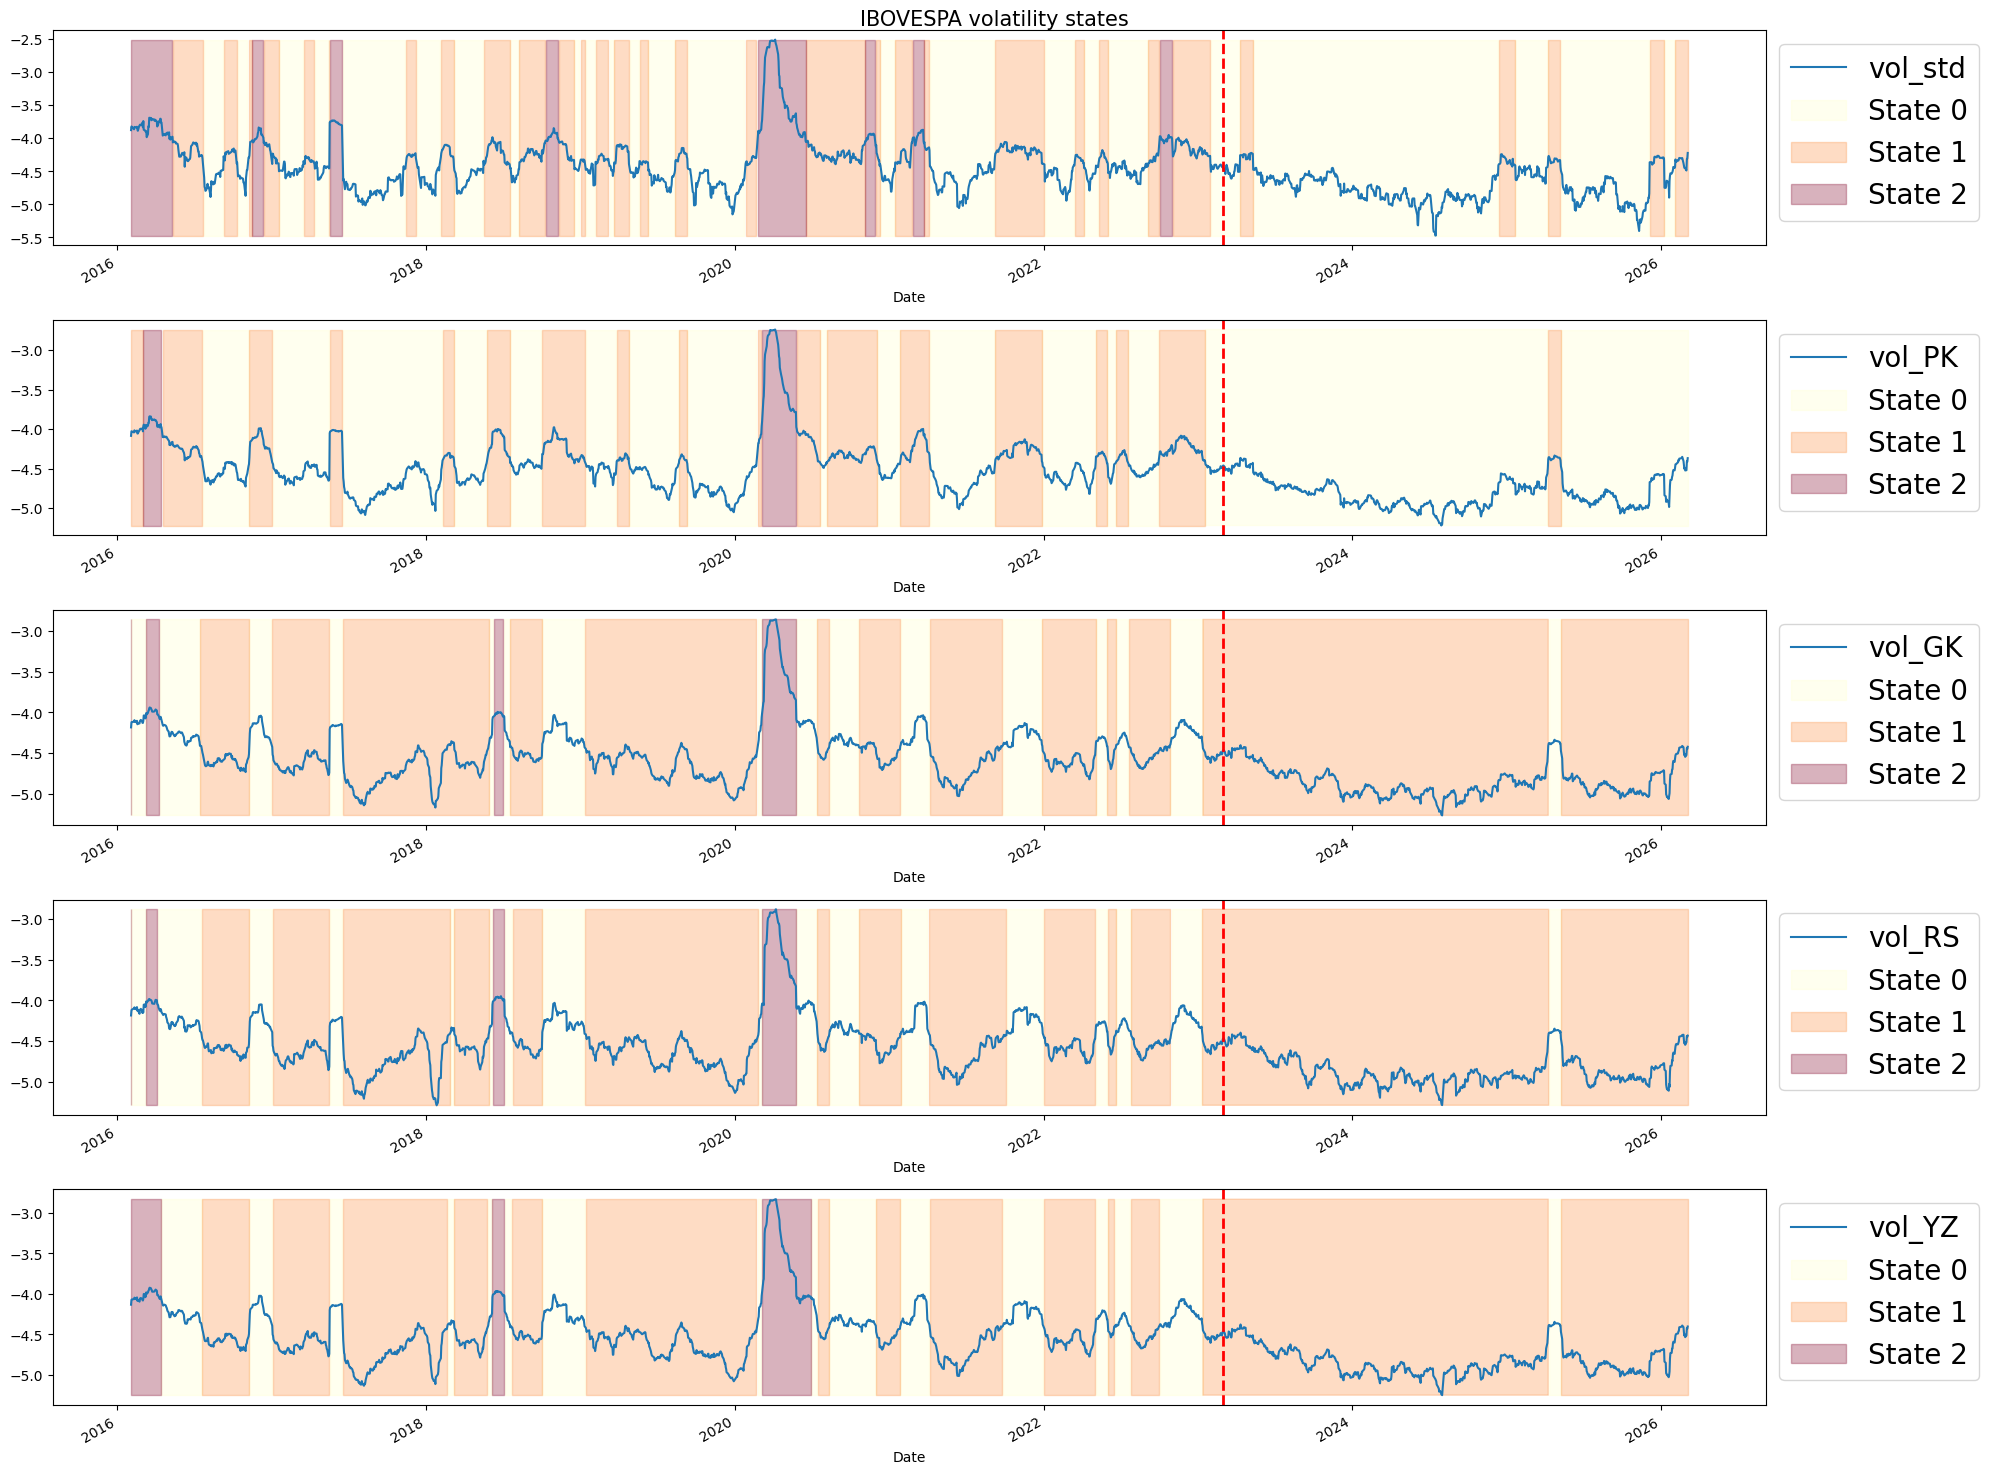

In [14]:
fig,axs = plt.subplots(5,1,figsize=(20,15))

plot_states_and_series(dataset,"vol_std","state_std",axs[0],cut_value)
plot_states_and_series(dataset,"vol_PK","state_PK",axs[1],cut_value)
plot_states_and_series(dataset,"vol_GK","state_GK",axs[2],cut_value)
plot_states_and_series(dataset,"vol_RS","state_RS",axs[3],cut_value)
plot_states_and_series(dataset,"vol_YZ","state_YZ",axs[4],cut_value)



fig.suptitle("IBOVESPA volatility states",fontsize=15)
plt.tight_layout(pad=1.1)

It is possible to observe that Parkinson model tends to be smoother along the transitions, while Close-To-Close model only switches between low and mid-vol. The same characterizations as mid in Close-To-Close are defined as high vol in the Parkinson model, leading to a conclusion that, for this situation, Parkinson volatility is more adequate to be modelled with GHMM. 

Nonetheless, it is possible to observe that HMM can "warn" about volatility increasing regimes, being a useful tool for risk management.